In [18]:
# Edge AI Energy Efficiency Project - PyTorch Analysis Notebook
# importing the required libraries
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importing PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# torchvision is used here to load the MNIST dataset
from torchvision import datasets, transforms
# dataLoader helps us load the data in batches
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
# create project folders
folders = ["models", "results", "plots"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created or already exist:", folders)

Folders created or already exist: ['models', 'results', 'plots']


In [20]:
# if GPU is not available, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# loading MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# batch_size means how many images the model sees at one time
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [22]:
# PyTorch model
# the input image size is 28 x 28, so the total input features are 784
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()

        # this changes the 28x28 image into one long vector
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x

# creating the model and sending it to CPU
model = MNISTModel().to(device)

print(model)

MNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [23]:
# train the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# number of times the model goes through the training dataset
epochs = 5

train_losses = []
train_accuracies = []

start_time = time.time()

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # calculating average loss and accuracy for this epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

training_time = time.time() - start_time

print("Training completed")
print("Training time:", round(training_time, 2), "seconds")

Epoch [1/5] - Loss: 0.2625, Accuracy: 92.19%
Epoch [2/5] - Loss: 0.1074, Accuracy: 96.71%
Epoch [3/5] - Loss: 0.0758, Accuracy: 97.62%
Epoch [4/5] - Loss: 0.0581, Accuracy: 98.17%
Epoch [5/5] - Loss: 0.0462, Accuracy: 98.52%
Training completed
Training time: 69.08 seconds


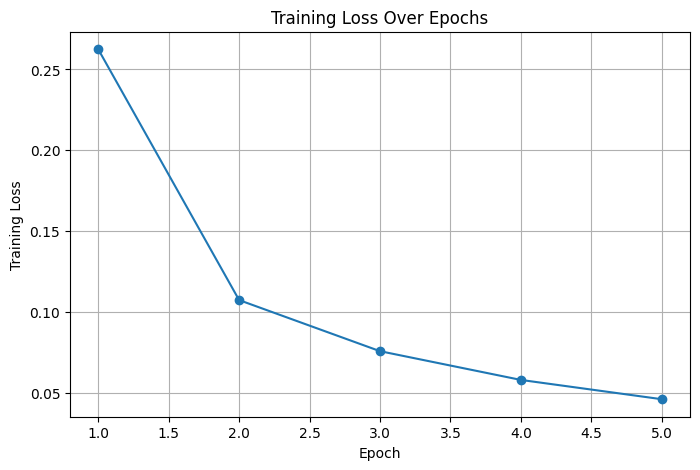

In [24]:
# graph for training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.savefig("plots/training_loss.png")
plt.show()

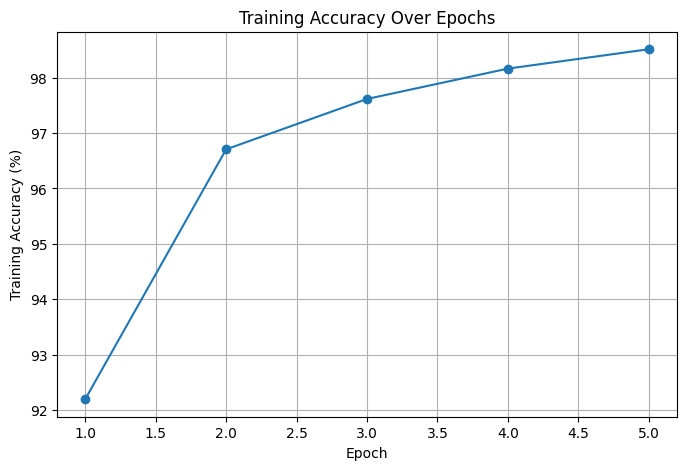

In [25]:
# graph for training accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Over Epochs")
plt.grid(True)
plt.savefig("plots/training_accuracy.png")
plt.show()